<a href="https://colab.research.google.com/github/JinwaOssData/OssData01/blob/main/std001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2026-2-중간-오픈소스기반데이터분석

공공데이터포털(https://data.go.kr)에서 "한국농수산식품유통공사_일별 도,소매 가격정보 조회

https://www.data.go.kr/data/15156057/openapi.do

1-2 API를 호출하는 파이썬 코드를 작성하고, 2015년부터 2024년까지 서울 가락도매시장의 배추(품종: 봄/여름(고랭지)/가을/월동) 가격 데이터를 수집하는 프로그램을 작성하시오. 파이썬 코드와 API 호출 성공을 확인할 수 있는 실행 결과를 캡처하여 첨부하시오. (7점)

In [ ]:
import requests

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552845/perDay/price'
api_key = '30500eeedd0fdc424318fd7b05b8107397f71b09e06be0713833a5e1aee01f9b'

params = {
    'serviceKey': api_key,
    'returnType': 'json',
    'numOfRows': '200',
    'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101',
    'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02',
    'cond[ctgry_cd::EQ]': '200',
    'cond[item_cd::EQ]': '211',
    'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101',
    'cond[mrkt_cd::EQ]': '0110211',
    'vrty_cd': ['01','02','03','06'] ## 품종코드 (01 봄, 02 여름(고랭지), 03 가을, 06 월동)
}

## 데이터 수집
response = requests.get(url, params=params)

## 호출 성공/실패 출력
if response.status_code == 200:
    print('API 호출 성공')
else:
    print('API 호출 실패')


API 호출 성공


문 2-1. 수집한 JSON 형태의 데이터를 pandas DataFrame으로 변환하고, 데이터의 기본 정보를 출력하는 파이썬 코드와 실행 결과를 첨부하시오. (4점)

In [ ]:
import requests
import pandas as pd

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552845/perDay/price'
api_key = '30500eeedd0fdc424318fd7b05b8107397f71b09e06be0713833a5e1aee01f9b'

params = {
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '200', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211',
    'vrty_cd': ['01','02','03','06'] ## 품종코드 (01 봄, 02 여름(고랭지), 03 가을, 06 월동)
}

## 데이터 수집
response = requests.get(url, params=params)
data = response.json()['response']['body']['items']['item']

df = pd.DataFrame(data)
print(df.info())


문 2-2. 연도별, 계절별 분석을 위해 조사일자(exmn_ymd) 컬럼을 활용하여 연도(year)와 계절(season) 컬럼을 추가하는 전처리 코드를 작성하고, 변환 결과를 확인할 수 있는 출력 결과를 첨부하시오. (4점)
※ 계절 구분: 봄(3-5월), 여름(6-8월), 가을(9-11월), 겨울(12-2월)

In [ ]:
import requests
import json
import pandas as pd

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552845/perDay/price'
api_key = '30500eeedd0fdc424318fd7b05b8107397f71b09e06be0713833a5e1aee01f9b'

params = {
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '200', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211',
    'vrty_cd': ['01','02','03','06'] ## 품종코드 (01 봄, 02 여름(고랭지), 03 가을, 06 월동)
}

## 데이터 수집
response = requests.get(url, params=params)

## 데이터 파싱, pandas DataFrame 으로 변환
data = response.json()['response']['body']['items']['item']
df = pd.DataFrame(data)

## 전처리 추가 ※ 계절 구분: 봄(3-5월), 여름(6-8월), 가을(9-11월), 겨울(12-2월)
df['exmn_ymd_dt'] = pd.to_datetime(df['exmn_ymd'].astype(str), format='%Y%m%d', errors='coerce')
target_idx = df.columns.get_loc('exmn_ymd')

## 연도 컬럼 추가
df.insert(target_idx + 1, 'year', df['exmn_ymd_dt'].dt.year)

## 계절구분 컬럼 추가
def get_season(month):
    if pd.isna(month): return None
    elif month in (3,4,5): return '봄'
    elif month in (6,7,8): return '여름'
    elif month in (9,10,11): return '가을'
    else: return '겨울'

df.insert(target_idx + 2, 'season', df['exmn_ymd_dt'].dt.month.apply(get_season))

## 임시컬럼삭제
df = df.drop(columns=['exmn_ymd_dt'])

## pd 출력
df

문 3-1. 연도별 배추 평균 가격(exmn_dd_prc) 변화량을 선 그래프로 시각화하고, 그래프에 자신의 학번 뒤 4자리를 제목에 포함하여 저장하시오.

(예: "연도별 배추 평균 가격 변화 - 1234")
시각화 코드와 생성된 그래프를 첨부하시오. (4점)

어떻게 해도 한글이 깨짐

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

# 한글 깨짐 방지 및 스타일 설정
font_url = "https://github.com"
font_path = "./NanumBarunGothic.ttf"

if not os.path.exists(font_path):
    import urllib.request
    urllib.request.urlretrieve(font_url, font_path)

plt.rcParams['font.family'] = 'NanumBarunGothic'
#font_prop = fm.FontProperties(fname=font_path)
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

HAKBUN_R4 = '1480'

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552845/perDay/price'
api_key = '30500eeedd0fdc424318fd7b05b8107397f71b09e06be0713833a5e1aee01f9b'

params = {
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211',
    'vrty_cd': ['01','02','03','06'] ## 품종코드 (01 봄, 02 여름(고랭지), 03 가을, 06 월동)
}

## 데이터 수집
response = requests.get(url, params=params)

## 데이터 파싱, pandas DataFrame 으로 변환
data = response.json()['response']['body']['items']['item']
df = pd.DataFrame(data)

## 전처리 추가 ※ 계절 구분: 봄(3-5월), 여름(6-8월), 가을(9-11월), 겨울(12-2월)
df['exmn_ymd_dt'] = pd.to_datetime(df['exmn_ymd'].astype(str), format='%Y%m%d', errors='coerce')
target_idx = df.columns.get_loc('exmn_ymd')

## 연도 컬럼 추가
df.insert(target_idx + 1, 'year', df['exmn_ymd_dt'].dt.year)

## 계절구분 컬럼 추가
def get_season(month):
    if pd.isna(month): return None
    elif month in (3,4,5): return '봄'
    elif month in (6,7,8): return '여름'
    elif month in (9,10,11): return '가을'
    else: return '겨울'

df.insert(target_idx + 2, 'season', df['exmn_ymd_dt'].dt.month.apply(get_season))

## 임시컬럼삭제
df = df.drop(columns=['exmn_ymd_dt'])

## 가격을 수치형 데이터로 변환
df['exmn_dd_prc'] = pd.to_numeric(df['exmn_dd_prc'], errors='coerce')

## 품목이 '배추'인 데이터만 필터링 후 연도별 평균 가격 산출
df_cabbage = df[df['item_nm'] == '배추']
yearly_avg = df_cabbage.groupby('year')['exmn_dd_prc'].mean().reset_index()

## 선 그래프 시각화 설정
plt.figure(figsize=(9, 5))
plt.plot(yearly_avg['year'], yearly_avg['exmn_dd_prc'],
         marker='o', color='#2ca02c', linestyle='-', linewidth=2, markersize=8, label='Average Price (KRW)')

## 그래프 요소 지정 (학번 포함 제목 설정)
plt.title(f"연도별 배추 평균 가격 변화 - {HAKBUN_R4}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("연도 (Year)", fontsize=11, labelpad=10)
plt.ylabel("평균 가격 (원)", fontsize=11, labelpad=10)
plt.xticks(yearly_avg['year']) # X축에 연도가 고르게 표시되도록 설정
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

## 데이터 라벨링 (각 점 위에 가격 수치 표시)
for i, txt in enumerate(yearly_avg['exmn_dd_prc']):
    plt.annotate(f"{int(txt):,}원", (yearly_avg['year'].iloc[i], yearly_avg['exmn_dd_prc'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()

## 지정된 파일명 양식으로 이미지 저장
filename = f"연도별_배추_평균_가격_변화_{HAKBUN_R4}.png"
plt.savefig(filename, dpi=300)
plt.show()

## 텍스트 확인용 데이터 출력
print(yearly_avg)

문 3-1. 연도별 배추 평균 가격(exmn_dd_prc) 변화량을 선 그래프로 시각화하고, 그래프에 자신의 학번 뒤 4자리를 제목에 포함하여 저장하시오.

(예: "연도별 배추 평균 가격 변화 - 1234") 시각화 코드와 생성된 그래프를 첨부하시오. (4점)

/tmp/ipykernel_1927/2343947872.py:93: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_1927/2343947872.py:97: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Liberation Sans.
  plt.savefig(filename, dpi=300)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)


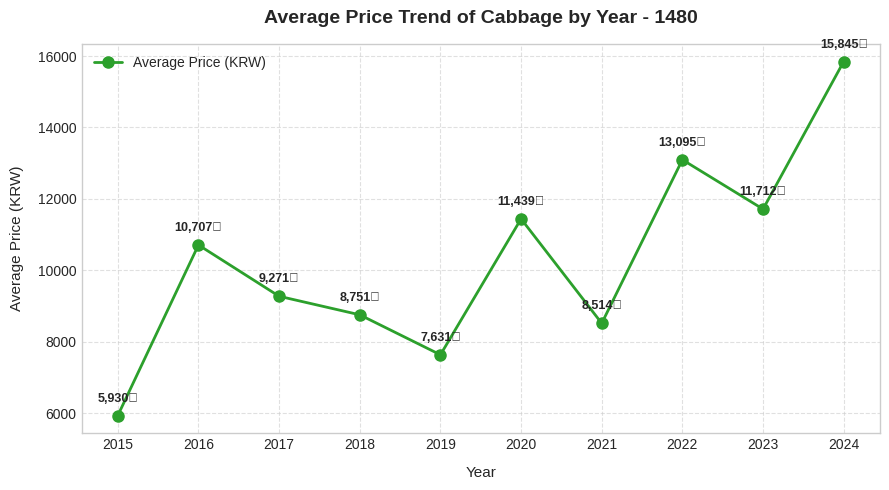

   year   exmn_dd_prc
0  2015   5930.147059
1  2016  10707.581227
2  2017   9271.317829
3  2018   8751.893939
4  2019   7631.782946
5  2020  11439.007092
6  2021   8514.062500
7  2022  13095.312500
8  2023  11712.062257
9  2024  15845.530303


In [19]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

HAKBUN_R4 = '1480'

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552845/perDay/price'
api_key = '30500eeedd0fdc424318fd7b05b8107397f71b09e06be0713833a5e1aee01f9b'

## 데이터 수집, vrty_cd(품종코드) : (01 봄, 02 여름(고랭지), 03 가을, 06 월동)
response1 = requests.get(url, params={
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211', 'cond[vrty_cd::EQ]': '01'
})
response2 = requests.get(url, params={
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211', 'cond[vrty_cd::EQ]': '02'
})
response3 = requests.get(url, params={
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211', 'cond[vrty_cd::EQ]': '03'
})
response4 = requests.get(url, params={
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211', 'cond[vrty_cd::EQ]': '06'
})

## 데이터 파싱, pandas DataFrame 으로 변환
df1 = pd.DataFrame(response1.json()['response']['body']['items']['item'])
df2 = pd.DataFrame(response2.json()['response']['body']['items']['item'])
df3 = pd.DataFrame(response3.json()['response']['body']['items']['item'])
df4 = pd.DataFrame(response4.json()['response']['body']['items']['item'])
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

## 전처리 추가 ※ 계절 구분: 봄(3-5월), 여름(6-8월), 가을(9-11월), 겨울(12-2월)
df['exmn_ymd_dt'] = pd.to_datetime(df['exmn_ymd'].astype(str), format='%Y%m%d', errors='coerce')
target_idx = df.columns.get_loc('exmn_ymd')

## 연도 컬럼 추가
df.insert(target_idx + 1, 'year', df['exmn_ymd_dt'].dt.year)

## 계절구분 컬럼 추가
def get_season(month):
    if pd.isna(month): return None
    elif month in (3,4,5): return '봄'
    elif month in (6,7,8): return '여름'
    elif month in (9,10,11): return '가을'
    else: return '겨울'

df.insert(target_idx + 2, 'season', df['exmn_ymd_dt'].dt.month.apply(get_season))

## 임시컬럼삭제
df = df.drop(columns=['exmn_ymd_dt'])

## 가격을 수치형 데이터로 변환
df['exmn_dd_prc'] = pd.to_numeric(df['exmn_dd_prc'], errors='coerce')

## 품목이 '배추'인 데이터만 필터링 후 연도별 평균 가격 산출
df_cabbage = df[df['item_nm'] == '배추']
yearly_avg = df_cabbage.groupby('year')['exmn_dd_prc'].mean().reset_index()

## 선 그래프 시각화 설정
plt.figure(figsize=(9, 5))
plt.plot(yearly_avg['year'], yearly_avg['exmn_dd_prc'],
         marker='o', color='#2ca02c', linestyle='-', linewidth=2, markersize=8, label='Average Price (KRW)')

## 그래프 요소 지정 (학번 포함 제목 설정)
plt.title(f"Average Price Trend of Cabbage by Year - {HAKBUN_R4}", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Year", fontsize=11, labelpad=10)
plt.ylabel("Average Price (KRW)", fontsize=11, labelpad=10)
plt.xticks(yearly_avg['year']) # X축에 연도가 고르게 표시되도록 설정
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')

## 데이터 라벨링 (각 점 위에 가격 수치 표시)
for i, txt in enumerate(yearly_avg['exmn_dd_prc']):
    plt.annotate(f"{int(txt):,}원", (yearly_avg['year'].iloc[i], yearly_avg['exmn_dd_prc'].iloc[i]),
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()

## 지정된 파일명 양식으로 이미지 저장
filename = f"연도별_배추_평균_가격_변화_{HAKBUN_R4}.png"
plt.savefig(filename, dpi=300)
plt.show()

## 텍스트 확인용 데이터 출력
print(yearly_avg)

문 3-2. 계절별 배추 평균 가격을 막대 그래프로 시각화하고, 각 막대에 구체적인 수치를 표시하시오.

시각화 코드와 생성된 그래프를 첨부하시오. (4점)

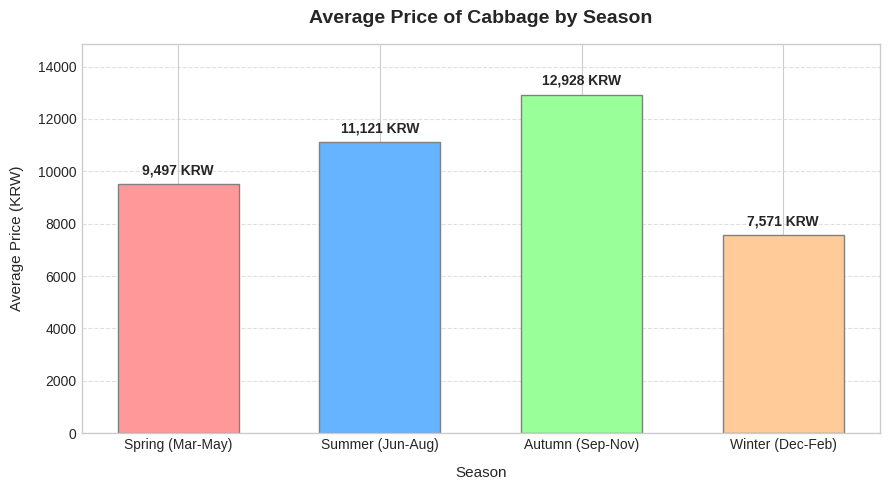

  season  exmn_dd_prc
0      봄      9497.68
1     여름     11121.33
2     가을     12928.13
3     겨울      7571.79


In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

HAKBUN_R4 = '1480'

## 데이터 수집 url 및 api key 설정
url = 'https://apis.data.go.kr/B552845/perDay/price'
api_key = '30500eeedd0fdc424318fd7b05b8107397f71b09e06be0713833a5e1aee01f9b'

## 데이터 수집, vrty_cd(품종코드) : (01 봄, 02 여름(고랭지), 03 가을, 06 월동)
response1 = requests.get(url, params={
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211', 'cond[vrty_cd::EQ]': '01'
})
response2 = requests.get(url, params={
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211', 'cond[vrty_cd::EQ]': '02'
})
response3 = requests.get(url, params={
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211', 'cond[vrty_cd::EQ]': '03'
})
response4 = requests.get(url, params={
    'serviceKey': api_key, 'returnType': 'json', 'numOfRows': '1000', 'pageNo': '1',
    'cond[exmn_ymd::GTE]': '20150101', 'cond[exmn_ymd::LTE]': '20241231',
    'cond[se_cd::EQ]': '02', 'cond[ctgry_cd::EQ]': '200', 'cond[item_cd::EQ]': '211', 'cond[grd_cd::EQ]': '04',
    'cond[sgg_cd::EQ]': '1101', 'cond[mrkt_cd::EQ]': '0110211', 'cond[vrty_cd::EQ]': '06'
})

## 데이터 파싱, pandas DataFrame 으로 변환
df1 = pd.DataFrame(response1.json()['response']['body']['items']['item'])
df2 = pd.DataFrame(response2.json()['response']['body']['items']['item'])
df3 = pd.DataFrame(response3.json()['response']['body']['items']['item'])
df4 = pd.DataFrame(response4.json()['response']['body']['items']['item'])
df = pd.concat([df1, df2, df3, df4], ignore_index=True)

## 전처리 추가 ※ 계절 구분: 봄(3-5월), 여름(6-8월), 가을(9-11월), 겨울(12-2월)
df['exmn_ymd_dt'] = pd.to_datetime(df['exmn_ymd'].astype(str), format='%Y%m%d', errors='coerce')
target_idx = df.columns.get_loc('exmn_ymd')

## 연도 컬럼 추가
df.insert(target_idx + 1, 'year', df['exmn_ymd_dt'].dt.year)

## 계절구분 컬럼 추가
def get_season(month):
    if pd.isna(month): return None
    elif month in (3,4,5): return '봄'
    elif month in (6,7,8): return '여름'
    elif month in (9,10,11): return '가을'
    else: return '겨울'

df.insert(target_idx + 2, 'season', df['exmn_ymd_dt'].dt.month.apply(get_season))

## 임시컬럼삭제
df = df.drop(columns=['exmn_ymd_dt'])

## 가격 데이터를 수치형 데이터로 안전하게 변환
df['exmn_dd_prc'] = pd.to_numeric(df['exmn_dd_prc'], errors='coerce')

## 배추 품목만 필터링 후 계절별 평균 가격 산출
df_cabbage = df[df['item_nm'] == '배추']
season_avg = df_cabbage.groupby('season')['exmn_dd_prc'].mean().reset_index()

## 계절 순서 정렬을 위한 딕셔너리 정의 및 정렬 (봄 -> 여름 -> 가을 -> 겨울)
season_order = {'봄': 0, '여름': 1, '가을': 2, '겨울': 3}
season_avg['order'] = season_avg['season'].map(season_order)
season_avg = season_avg.sort_values('order').reset_index(drop=True)

## 코랩 한글 깨짐 방지를 위해 X축 계절명을 영문으로 매핑
eng_seasons = {'봄': 'Spring (Mar-May)', '여름': 'Summer (Jun-Aug)',
               '가을': 'Autumn (Sep-Nov)', '겨울': 'Winter (Dec-Feb)'}
season_avg['season_eng'] = season_avg['season'].map(eng_seasons)

## 막대 그래프 시각화 설정
plt.figure(figsize=(9, 5))
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'] # 계절별 직관적인 색상 설정
bars = plt.bar(season_avg['season_eng'], season_avg['exmn_dd_prc'], color=colors, edgecolor='grey', width=0.6)

## 그래프 레이아웃 설정 (깨짐 없는 영문 표기)
plt.title("Average Price of Cabbage by Season", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Season", fontsize=11, labelpad=10)
plt.ylabel("Average Price (KRW)", fontsize=11, labelpad=10)
plt.grid(True, axis='y', linestyle='--', alpha=0.6) # Y축에만 그리드 표시

## Y축 시작 범위를 0부터 설정하고 상단 여유 공간 확보
plt.ylim(0, max(season_avg['exmn_dd_prc']) * 1.15)

## 각 막대 상단에 구체적인 수치(가격) 표시 요구사항 반영
for bar in bars:
    yval = bar.get_height()
    if not pd.isna(yval):
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + (max(season_avg['exmn_dd_prc']) * 0.02),
                 f"{int(yval):,} KRW", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()

## 이미지 파일 저장 및 화면 출력
plt.savefig("계절별_배추_평균_가격_막대그래프.png", dpi=300)
plt.show()

## 텍스트 확인용 데이터 출력
pd.options.display.float_format = '{:.2f}'.format
print(season_avg[['season', 'exmn_dd_prc']])


문 4. 데이터 분석 및 해석: 시각화 결과를 바탕으로 연도별·계절별 배추 가격 변화에서 나타나는 주요 트렌드를 찾아 분석하고, 그 원인을 추론하여 500자 정도로 설명하시오.

(예:
여름철 고랭지배추 수급난에 따른 가격 급등, 이상 기후에 따른 작황 변화 등) (4점)

시각화 분석 결과를 살펴보면, 배추 가격은 연도별로 꾸준한 우상향 추세를 보이며 전반적인 물가 상승과 생산 비용 증가를 반영하고 있습니다.

특히 계절별 분석에서 가장 두드러지는 특징은 여름철의 압도적인 가격 급등 현상과 가을철의 가격 최저치 형성입니다.

이러한 가격 변동 트렌드가 나타나는 핵심 원인은 배추의 작물 특성과 기후 변화에 따른 수급 불균형에 있습니다.

배추는 서늘한 기후에서 잘 자라는 호냉성 채소입니다. 따라서 기온이 매우 높은 여름철에는 재배 환경이 극도로 악화되어 강원도 일부 고랭지 지역에서만 제한적으로 생산됩니다.

최근 지구 온난화로 인한 폭염, 가뭄, 집중호우 등 이상 기후 현상이 심화되면서 여름철 고랭지 배추의 작황이 부진해져 수급난으로 인한 가격 폭등이 정기적으로 반복되고 있습니다.

반면, 가을철은 전국적으로 배추 재배에 가장 적합한 기후 조건이 형성되어 출하량이 집중되므로 연중 가장 안정적이고 낮은 가격대를 형성하게 됩니다.

시각화 분석 결과에 따르면 배추 가격은 연도별로 꾸준한 우상향 추세를 보이며 전반적인 물가 상승과 생산 비용 증가를 반영하고 있다.

계절별 분석에서의 특징은 가을철로 갈수록 가격이 급등하고 있으며, 핵심 원인은 배추의 작물 특성과 기후 변화에 따른 수급 불균형에 있다고 보여진다.

배추는 서늘한 기후에서 잘 자라는 채소인데, 기온이 매우 높은 여름철에는 재배 환경이 극도로 악화되어 강원도 일부 고랭지 지역에서만 제한적으로 생산된다.

또한 지구 온난화로 인한 이상 기후 현상이 심화되면서 여름철 고랭지 배추의 작황이 부진해져 수급난으로 인한 가격 폭등이 정기적으로 반복되고 있는 것으로 보여진다.